# 西班牙电力：EDA 与提前 1 小时的发电量预测

这是一份面试练习 notebook，使用公开的西班牙小时电力数据；**并未确认它就是 Squarepoint 的面试原始数据或题目**。

默认任务：在时刻 \(t\) 已获得该小时的观测后，预测 \(t+1\) 小时的**陆上风电发电功率**（`generation wind onshore`，MW）。同一流程可以迁移到太阳能或其他发电来源。这里的 MW 是功率单位，不应直接标成 MWh。

内容包括数据审计、缺失值、趋势与周期、相关性、朴素基线、传统自回归 AR、Ridge、Extra Trees、HistGradientBoosting，以及按时间留出的评估。全部方法均为非深度学习方法。

**先讲清楚预测协议：**验证和测试使用“逐小时滚动的一步预测”：每经过一个小时，可以用刚观测到的真实值构造下一次预测的历史特征；模型参数在该评估区间内保持固定。它与“在 2017 年底一次性预测整个 2018 年”是不同任务。

数据来源：[Kaggle 原始页面](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)。免登录下载地址来自 [Lightning 的公开教程](https://lightning-flash.readthedocs.io/en/stable/notebooks/flash_tutorials/electricity_forecasting.html)，压缩包同时含电力与天气数据。本 notebook 使用电力表；不合并天气实测值，避免把未来才会知道的天气当作预测时已知信息。


## 1. 环境与实验约定

需要 Python 3.10+、NumPy、pandas、Matplotlib、scikit-learn。首次使用可取消下一格安装命令的注释，再重启 kernel。首次运行会下载约 4 MB 压缩包并缓存到当前工作目录的 `data/`。

固定配置：2015–2016 年训练，2017 年验证，2018 年最终测试。为保持时间间隔严格为 1 小时，切分边界使用 **UTC**；日内、星期等日历特征按 **Europe/Madrid** 生成。UTC 边界与当地午夜可能相差 1 小时，这是有意的约定。

候选模型和预测非负截断规则预先确定；只根据验证集 MAE 选模型。测试集只在选择完成、训练集与验证集合并重拟合之后使用。


In [1]:
# 如缺少依赖，取消下一行注释运行；安装后重启 kernel。
# %pip install numpy pandas matplotlib scikit-learn

from pathlib import Path
from urllib.request import urlopen
import shutil
import zipfile
import time
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

SEED = 42
TARGET = "generation wind onshore"
HORIZON = 1
assert HORIZON == 1, "本练习实现一步预测；改变步长时，必须重新定义所有 lag 和评估协议。"

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
ZIP_PATH = DATA_DIR / "kaggle_electricity.zip"
DATA_URL = "https://pl-flash-data.s3.amazonaws.com/kaggle_electricity.zip"
LOCAL_TZ = "Europe/Madrid"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.titlesize": 12, "axes.labelsize": 10})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)


## 2. 下载与结构审计

优先读取本地缓存。读取 ZIP 中指定的 CSV，不向任意目录解压文件。数据的原始时区字符串含冬令时与夏令时偏移，必须统一转换为 UTC，不能直接删除时区或按字符串排序。

先检查时间戳唯一性与顺序，再补齐小时索引。新增的小时只产生缺失值，**不会凭空生成标签**。这里的全量检查仅用于结构审计；后面的分布分析和模型选择使用训练/验证区间。


In [2]:
if not ZIP_PATH.exists():
    # 先写临时文件，下载完整后原子替换，避免中途断网留下“看似完整”的缓存。
    temporary_path = ZIP_PATH.with_suffix(".zip.part")
    with urlopen(DATA_URL, timeout=120) as response, temporary_path.open("wb") as output_file:
        shutil.copyfileobj(response, output_file)
    temporary_path.replace(ZIP_PATH)

assert zipfile.is_zipfile(ZIP_PATH), "缓存不是有效 ZIP；删除 data/kaggle_electricity.zip 后重试。"
with zipfile.ZipFile(ZIP_PATH) as archive:
    assert "energy_dataset.csv" in archive.namelist()
    with archive.open("energy_dataset.csv") as csv_file:
        raw = pd.read_csv(csv_file)

assert "time" in raw.columns and TARGET in raw.columns
timestamps = pd.to_datetime(raw.pop("time"), utc=True, errors="raise")
assert not timestamps.isna().any(), "存在无法使用的时间戳。"
assert not timestamps.duplicated().any(), "同一 UTC 小时重复：应先查明来源，再决定如何聚合。"

energy = raw.apply(pd.to_numeric, errors="raise")
energy.index = pd.DatetimeIndex(timestamps, name="time")
energy = energy.sort_index()
original_row_count = len(energy)
energy = energy.asfreq("h")

assert energy.index.is_monotonic_increasing and energy.index.is_unique
assert (energy.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()

display(pd.Series({
    "原始行数": original_row_count,
    "补齐后行数": len(energy),
    "新增缺失小时数": len(energy) - original_row_count,
    "数值列数": energy.shape[1],
    "开始时间 UTC": str(energy.index.min()),
    "结束时间 UTC": str(energy.index.max()),
    "目标缺失标签数": int(energy[TARGET].isna().sum()),
}, name="结构审计"))
display(energy.head())


原始行数                            35064
补齐后行数                           35064
新增缺失小时数                             0
数值列数                               28
开始时间 UTC    2014-12-31 23:00:00+00:00
结束时间 UTC    2018-12-31 22:00:00+00:00
目标缺失标签数                            18
Name: 结构审计, dtype: object

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,...,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,...,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,...,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,...,NaN,5454.0,23515.0,22734.0,47.33,64.48
2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,...,NaN,5151.0,22642.0,21286.0,42.27,59.32
2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,...,NaN,4861.0,21785.0,20264.0,38.41,56.04


## 3. 训练期 EDA：缺失、常量列和目标分布

全部 EDA 分布统计限定在训练区间。先检查哪些列全空或恒为零，避免直接把整张表丢给模型。全零的发电来源、抽水蓄能用电列与预测列具有不同含义，不能简单求和并当成总发电或总负荷。

目标缺失的小时保留在原始时间轴中，后面不参与拟合或评分。目标偏斜、负值和异常波动值得检查，但不能仅因为数值极端就删除真实天气事件。

还要检查大幅跳变出现的时间：如果反复集中在当地午夜，应优先核查原始记录、日期解析、每日数据拼接或发布时间，而不是直接解释成天气事件。下方列出训练期最大的 20 次小时跳变；这里只标记问题，不在缺少证据时自动修复或删行。


,missing_count,missing_pct,zero_pct,distinct_nonmissing
generation hydro pumped storage aggregated,17544,100.00,0.00,0
forecast wind offshore eday ahead,17544,100.00,0.00,0
total load actual,32,0.18,0.00,10900
generation marine,18,0.10,99.90,1
generation hydro pumped storage consumption,18,0.10,33.12,2838
generation biomass,18,0.10,0.00,420
generation fossil oil,18,0.10,0.00,312
generation hydro run-of-river and poundage,18,0.10,0.00,1588
generation waste,18,0.10,0.00,247
generation fossil coal-derived gas,17,0.10,99.90,1


,target_MW
count,17527.000000
mean,5446.360244
std,3259.023800
min,234.000000
25%,2856.000000
50%,4808.000000
75%,7395.500000
max,17436.000000


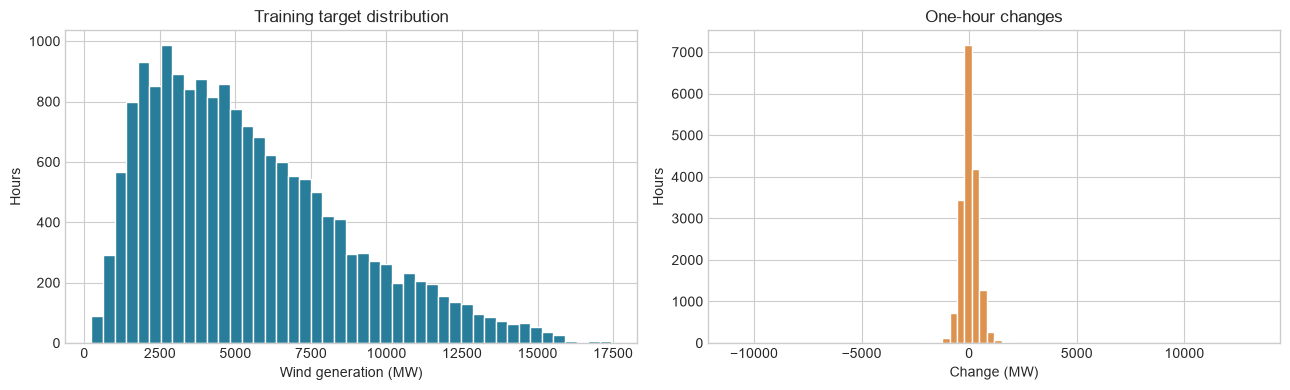

,absolute_change_MW,local_time,local_hour
time,,,
2016-02-12 23:00:00+00:00,13236.0,2016-02-13 00:00:00+01:00,0
2015-05-01 22:00:00+00:00,11766.0,2015-05-02 00:00:00+02:00,0
2015-01-11 23:00:00+00:00,10919.0,2015-01-12 00:00:00+01:00,0
2016-12-01 23:00:00+00:00,10413.0,2016-12-02 00:00:00+01:00,0
2015-01-31 23:00:00+00:00,10089.0,2015-02-01 00:00:00+01:00,0
2016-03-01 23:00:00+00:00,10078.0,2016-03-02 00:00:00+01:00,0
2015-04-02 22:00:00+00:00,9950.0,2015-04-03 00:00:00+02:00,0
2016-09-30 22:00:00+00:00,9868.0,2016-10-01 00:00:00+02:00,0
2016-06-30 22:00:00+00:00,9861.0,2016-07-01 00:00:00+02:00,0


训练期最大 20 次小时跳变中，当地 00:00 出现 19 次。
时间集中性值得核查，但仅凭这张表不能断言原因；本练习仍保留原始记录。


In [3]:
TRAIN_START = pd.Timestamp("2015-01-01", tz="UTC")
VAL_START = pd.Timestamp("2017-01-01", tz="UTC")
TEST_START = pd.Timestamp("2018-01-01", tz="UTC")
TEST_END = pd.Timestamp("2019-01-01", tz="UTC")

eda = energy.loc[(energy.index >= TRAIN_START) & (energy.index < VAL_START)].copy()
audit = pd.DataFrame({
    "missing_count": eda.isna().sum(),
    "missing_pct": eda.isna().mean().mul(100),
    "zero_pct": eda.eq(0).mean().mul(100),
    "distinct_nonmissing": eda.nunique(dropna=True),
})
display(audit.sort_values(["missing_pct", "zero_pct"], ascending=False).round(2))
display(eda[TARGET].describe().to_frame("target_MW"))
assert eda[TARGET].dropna().ge(0).all(), "目标出现负值，应先检查单位和数据含义。"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
eda[TARGET].hist(bins=45, ax=axes[0], color="#287d9b", edgecolor="white")
axes[0].set(title="Training target distribution", xlabel="Wind generation (MW)", ylabel="Hours")
eda[TARGET].diff().hist(bins=70, ax=axes[1], color="#dd9250", edgecolor="white")
axes[1].set(title="One-hour changes", xlabel="Change (MW)", ylabel="Hours")
plt.tight_layout()
plt.show()

# 在完整小时轴上计算变化，保留缺失值，避免把跨缺失小时的变化误认为一小时变化。
jump_audit = pd.DataFrame({"absolute_change_MW": eda[TARGET].diff().abs()})
jump_audit["local_time"] = jump_audit.index.tz_convert(LOCAL_TZ)
jump_audit["local_hour"] = jump_audit.index.tz_convert(LOCAL_TZ).hour
largest_training_jumps = jump_audit.nlargest(20, "absolute_change_MW")
display(largest_training_jumps)
print(f"训练期最大 20 次小时跳变中，当地 00:00 出现 {largest_training_jumps['local_hour'].eq(0).sum()} 次。")
print("时间集中性值得核查，但仅凭这张表不能断言原因；本练习仍保留原始记录。")


## 4. 趋势、周期与自相关

小时噪声很强时，可以看日均值与月均值；下面使用平均功率，不把 MW 的简单加总误写为功率。日内和周内图是训练期的分组均值，不代表未来一定重复同样的规律。

自相关展示相隔 \(k\) 小时的观测是否相关。计算时保留完整小时索引，避免删除缺失行后把“相隔一行”误当成“相隔一小时”。短滞后相关性强，通常意味着 persistence 和 AR 是有竞争力的基线。


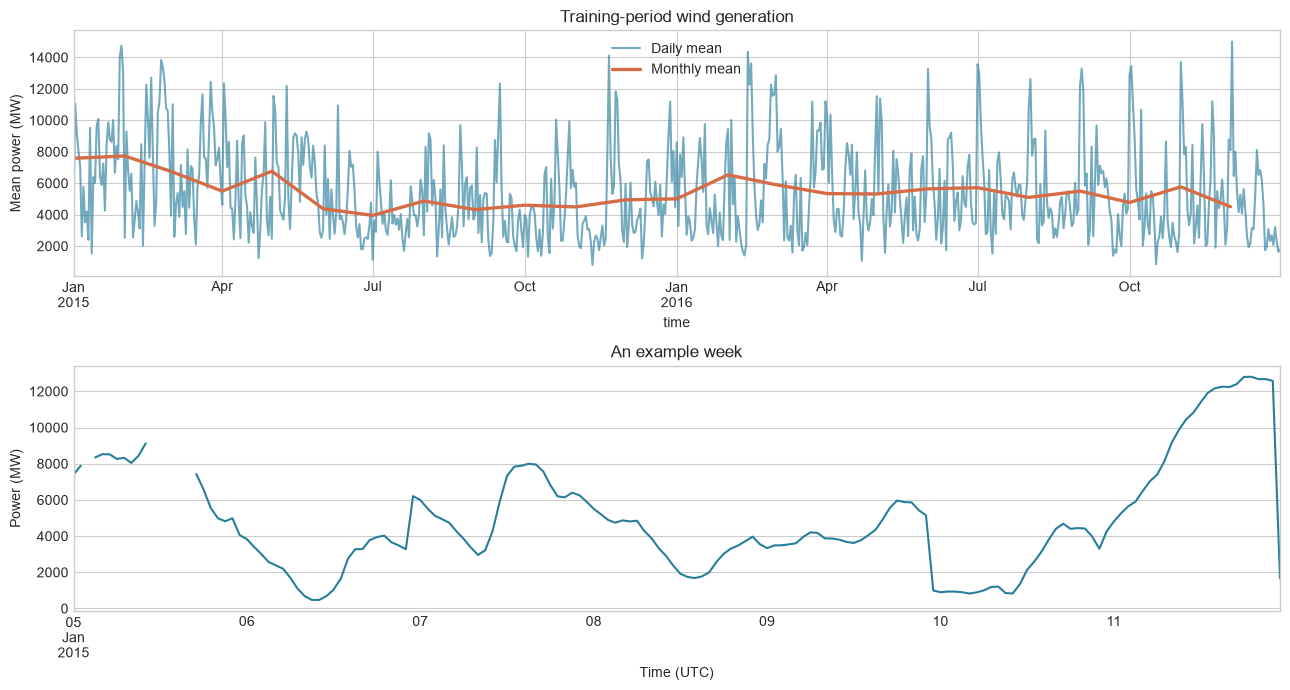

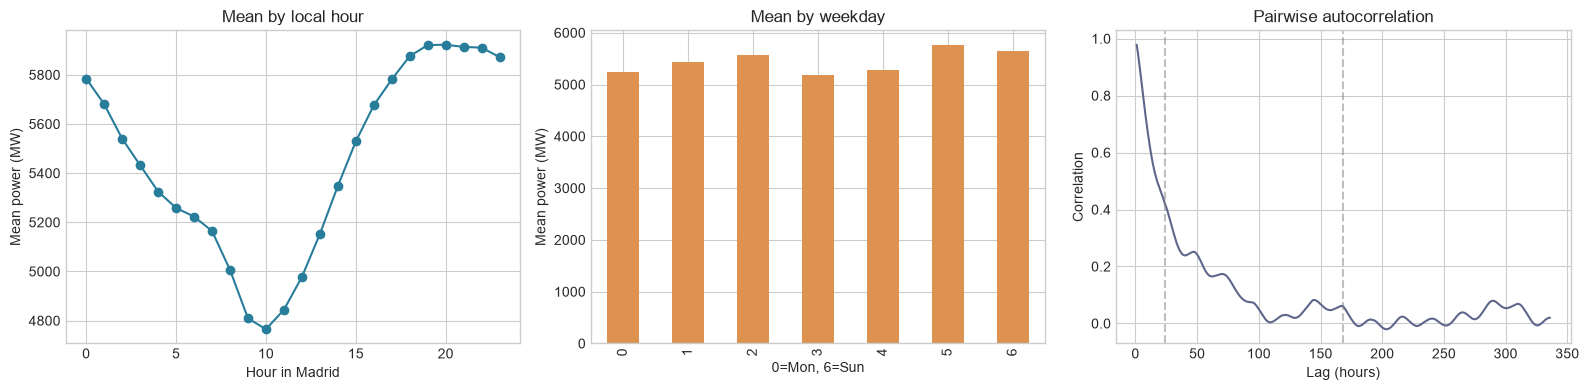

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
eda[TARGET].resample("D").mean().plot(ax=axes[0], alpha=0.65, label="Daily mean", color="#287d9b")
eda[TARGET].resample("ME").mean().plot(ax=axes[0], linewidth=2.4, label="Monthly mean", color="#d56c45")
axes[0].set(title="Training-period wind generation", ylabel="Mean power (MW)")
axes[0].legend()

# 选取完整的第一周看小时变化；这张图仍仅使用训练数据。
first_week = eda.loc["2015-01-05":"2015-01-11", TARGET]
first_week.plot(ax=axes[1], color="#287d9b")
axes[1].set(title="An example week", ylabel="Power (MW)", xlabel="Time (UTC)")
plt.tight_layout()
plt.show()

local_index = eda.index.tz_convert(LOCAL_TZ)
hour_profile = eda[TARGET].groupby(local_index.hour).mean()
weekday_profile = eda[TARGET].groupby(local_index.dayofweek).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hour_profile.plot(marker="o", ax=axes[0], color="#287d9b")
axes[0].set(title="Mean by local hour", xlabel="Hour in Madrid", ylabel="Mean power (MW)")
weekday_profile.plot(kind="bar", ax=axes[1], color="#dd9250")
axes[1].set(title="Mean by weekday", xlabel="0=Mon, 6=Sun", ylabel="Mean power (MW)")

# shift(k) 按规则小时索引移动 k 行，因此确实表示相隔 k 小时。
acf_lags = np.arange(1, 24 * 14 + 1)
acf_values = [eda[TARGET].corr(eda[TARGET].shift(int(k))) for k in acf_lags]
axes[2].plot(acf_lags, acf_values, color="#5e668c")
axes[2].axvline(24, color="grey", linestyle="--", alpha=0.5)
axes[2].axvline(168, color="grey", linestyle="--", alpha=0.5)
axes[2].set(title="Pairwise autocorrelation", xlabel="Lag (hours)", ylabel="Correlation")
plt.tight_layout()
plt.show()


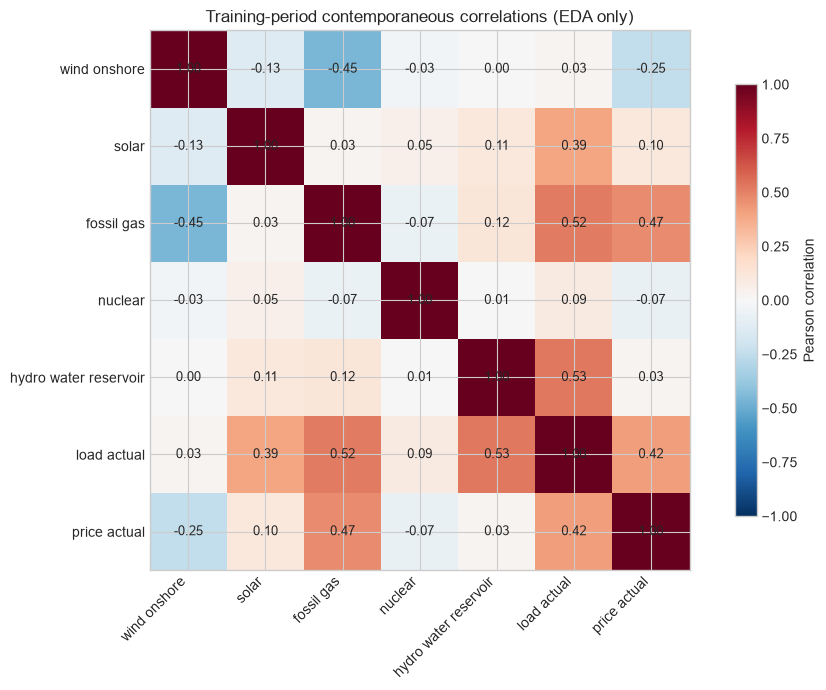

In [5]:
# 同时刻相关性只用于描述；建模时仍需按照可用时间把所有实测特征滞后。
correlation_columns = [
    TARGET, "generation solar", "generation fossil gas", "generation nuclear",
    "generation hydro water reservoir", "total load actual", "price actual",
]
correlation_columns = list(dict.fromkeys(correlation_columns))
corr = eda[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
short_names = [c.replace("generation ", "").replace("total load actual", "load actual") for c in corr.columns]
ax.set_xticks(range(len(corr)), short_names, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), short_names)
for row in range(len(corr)):
    for col in range(len(corr)):
        ax.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Training-period contemporaneous correlations (EDA only)")
fig.colorbar(im, ax=ax, label="Pearson correlation", shrink=0.8)
plt.tight_layout()
plt.show()


## 5. 定义信息可用时间，并构造特征

令每行索引 \(\tau\) 是**要预测的小时**，标签就是 \(y_\tau\)。本题在 \(\tau-1\) 时预测它，假设上一小时测量结果已及时公布。

| 要预测的小时 | 预测时最新可用小时 | 允许的目标历史 | 允许的其他来源观测 | 已知的日历 |
|---|---|---|---|---|
| 2018-01-01 01:00 UTC | 2018-01-01 00:00 UTC | \(y_{00:00},y_{23:00},\ldots\) | 00:00 及更早 | 目标小时的本地小时、星期 |

所以：

- lag 1/2/3/6/12/24/48/168 都来自过去；滚动均值和标准差必须先 `shift(1)`，再 `rolling(...)`。
- 其他发电来源与负荷实测列也必须滞后。**不能用目标小时的其他三个真实序列直接预测第四个未来序列**，除非题目明确说它们已知。
- 不使用 `forecast ...`、`price day ahead` 等发布时间未核实的字段。它们不一定泄漏，但需要先确认信息何时可得。
- 对历史特征最多向前填充 3 小时，只使用过去观测；剩余缺失由各模型在训练期学习的中位数处理。**标签始终来自未填充的原始数据**。
- 统一裁掉最初 168 小时，保证最长历史窗口已经开始；不随机打乱、不使用 `bfill`，也不做跨越未来的插值。

若实际电力数据有发布延迟，`shift(1)` 仍可能过于乐观；应把滞后改为“预测步长 + 发布延迟”。


In [6]:
TARGET_LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
AR_LAGS = [1, 2, 3, 24, 48, 168]
AR_COLUMNS = [f"target_lag_{lag}" for lag in AR_LAGS]

# 使用白名单，避免把未来实际值或来源不清楚的 forecast 列意外混入模型。
OBSERVED_COLUMNS = [
    "generation solar", "generation fossil gas", "generation nuclear",
    "generation hydro water reservoir", "generation hydro run-of-river and poundage",
    "generation biomass", "generation fossil hard coal", "generation fossil oil",
    "total load actual",
]
OBSERVED_COLUMNS = [column for column in OBSERVED_COLUMNS if column != TARGET]
assert all(column in energy.columns for column in OBSERVED_COLUMNS)

def make_features(frame):
    """每行对齐要预测的小时；所有实测信息严格早于该小时。"""
    features = pd.DataFrame(index=frame.index)

    # ffill 仅作用于历史特征副本；不会修改原始目标或生成新的训练标签。
    history_target = frame[TARGET].ffill(limit=3)
    for lag in TARGET_LAGS:
        features[f"target_lag_{lag}"] = history_target.shift(lag)

    # 先滞后再滚动：例如 tau 时刻的 24 小时均值使用 tau-24 到 tau-1。
    available_target = history_target.shift(HORIZON)
    for window in [6, 24, 168]:
        rolling = available_target.rolling(window=window, min_periods=window // 2)
        features[f"target_mean_{window}h"] = rolling.mean()
        features[f"target_std_{window}h"] = rolling.std()

    observed_history = frame[OBSERVED_COLUMNS].ffill(limit=3)
    for column in OBSERVED_COLUMNS:
        features[f"{column}__lag_1"] = observed_history[column].shift(1)
        features[f"{column}__lag_24"] = observed_history[column].shift(24)

    # 日历在预测前已知，不需要 shift；本地时钟保留西班牙夏令时的真实含义。
    local = frame.index.tz_convert(LOCAL_TZ)
    features["hour_sin"] = np.sin(2 * np.pi * local.hour / 24)
    features["hour_cos"] = np.cos(2 * np.pi * local.hour / 24)
    features["weekday_sin"] = np.sin(2 * np.pi * local.dayofweek / 7)
    features["weekday_cos"] = np.cos(2 * np.pi * local.dayofweek / 7)
    features["annual_sin"] = np.sin(2 * np.pi * (local.dayofyear - 1) / 365.25)
    features["annual_cos"] = np.cos(2 * np.pi * (local.dayofyear - 1) / 365.25)
    features["is_weekend"] = (local.dayofweek >= 5).astype(int)
    return features

X_all = make_features(energy)
y_all = energy[TARGET].copy()  # 注意：标签是原始值，绝不使用 history_target。

# 有效样本必须有真实标签；最初 168 小时作为历史预热区间，不拿来评分。
warmup_end = energy.index.min() + pd.Timedelta(hours=max(TARGET_LAGS))
eligible = y_all.notna() & (energy.index >= warmup_end)
eligible &= (energy.index >= TRAIN_START) & (energy.index < TEST_END)
X = X_all.loc[eligible].copy()
y = y_all.loc[eligible].copy()

assert X.index.equals(y.index)
assert y.notna().all()
assert y.equals(energy.loc[y.index, TARGET]), "标签必须保持原始观测值。"
# 缺失值允许留给训练期 imputer，但无穷值不是合法数值特征。
assert not np.isinf(X.to_numpy(dtype=float)).any()

display(pd.Series({
    "特征数": X.shape[1],
    "有真实标签的可用样本": len(X),
    "目标缺失排除小时数": int(y_all.isna().sum()),
    "最长历史窗口小时数": max(TARGET_LAGS),
}, name="特征工程概况"))


特征数              39
有真实标签的可用样本    34885
目标缺失排除小时数        18
最长历史窗口小时数       168
Name: 特征工程概况, dtype: int64

### 对因果性的实际检查

下面不只检查列名，而是**篡改某个未来区间的观测**，重新生成特征，确认预测该区间第一个小时及以前的特征完全不变。因为日历不变、实测信息都有至少 1 小时滞后，这个检查应该通过。

先生成所有时间点的因果特征再按时间切分是可行的；数据预处理中的中位数和标准化参数则必须放在 Pipeline 内，仅在相应训练块上拟合。


In [7]:
probe_time = pd.Timestamp("2017-06-01 00:00:00", tz="UTC")
perturbed = energy.copy()
change_mask = perturbed.index >= probe_time
columns_to_change = [TARGET] + OBSERVED_COLUMNS
perturbed.loc[change_mask, columns_to_change] = (
    perturbed.loc[change_mask, columns_to_change].fillna(0) + 100_000
)
features_after_change = make_features(perturbed)
pd.testing.assert_frame_equal(
    X_all.loc[:probe_time], features_after_change.loc[:probe_time],
    check_exact=False, atol=1e-8, rtol=1e-10,
)
del perturbed, features_after_change

train_mask = (X.index >= TRAIN_START) & (X.index < VAL_START)
val_mask = (X.index >= VAL_START) & (X.index < TEST_START)
test_mask = (X.index >= TEST_START) & (X.index < TEST_END)
X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

assert X_train.index.max() < X_val.index.min() < X_test.index.min()
assert not X_train.index.intersection(X_val.index).size
assert not X_val.index.intersection(X_test.index).size
assert X_train.notna().any().all(), "训练区间存在全空特征，应检查来源。"

split_rows = []
for name, frame in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    split_rows.append({"split": name, "samples": len(frame), "start_UTC": frame.index.min(), "end_UTC": frame.index.max()})
display(pd.DataFrame(split_rows).set_index("split"))
print("因果性扰动检查通过；每个标签均来自原始观测。")


,samples,start_UTC,end_UTC
split,,,
train,17367,2015-01-07 23:00:00+00:00,2016-12-31 23:00:00+00:00
validation,8760,2017-01-01 00:00:00+00:00,2017-12-31 23:00:00+00:00
test,8758,2018-01-01 00:00:00+00:00,2018-12-31 22:00:00+00:00


因果性扰动检查通过；每个标签均来自原始观测。


## 6. 模型：先有可解释的基线，再增加复杂度

| 方法 | 输入与作用 |
|---|---|
| Persistence | 下一小时等于上一小时，强自相关序列的重要基线 |
| Seasonal 24h / 168h | 用前一天 / 前一周同一 UTC 小时的值；夏令时附近不完全等于同一本地小时 |
| Sparse AR (OLS) | 只用目标自身的 lag 1/2/3/24/48/168，加截距，普通最小二乘估计 |
| Ridge | 目标历史 + 其他来源历史 + 日历；标准化后做 L2 正则线性回归 |
| Extra Trees | 非线性树集成，学习变量交互 |
| HistGradientBoosting | 逐步拟合误差的树模型 |

这里的 AR 形式为 \(y_\tau=c+\sum_{k\in\{1,2,3,24,48,168\}}\phi_k y_{\tau-k}+\epsilon_\tau\)。使用滞后设计矩阵与 `LinearRegression` 估计，就是传统的稀疏自回归模型；不一定需要调用某个名为 AR 的库函数。

**时序问题并不排斥回归方法。**关键是特征是否在预测时已知、是否有合理滞后、切分和评估是否尊重时间顺序。相反，随机划分的普通回归即使分数高，也可能回答了错误的问题。

所有输出统一截断到不小于 0 MW，这项规则在看验证分数前确定。树模型限制复杂度和并行度，避免面试环境运行过久。梯度提升关闭默认的随机 early-stopping 切分，避免把内部随机验证误当成时间验证。


In [8]:
class LagBaseline(RegressorMixin, BaseEstimator):
    """读取一个历史 lag；极少数历史缺失时退回训练标签中位数。"""
    def __init__(self, column):
        self.column = column

    def fit(self, X, y):
        # fallback 只从当前训练块估计，不读取验证/测试标签。
        self.fallback_ = float(np.median(np.asarray(y)))
        self.n_features_in_ = X.shape[1]
        return self

    def predict(self, X):
        return X[self.column].fillna(self.fallback_).to_numpy(dtype=float)


def make_model(name):
    """每次返回全新模型，确保最终重拟合不会沿用验证区间中的拟合状态。"""
    baseline_columns = {
        "Persistence": "target_lag_1",
        "Seasonal 24h": "target_lag_24",
        "Seasonal 168h": "target_lag_168",
    }
    if name in baseline_columns:
        return LagBaseline(baseline_columns[name])

    if name == "Sparse AR (OLS)":
        # AR 只接收自身历史，不使用外生特征；LinearRegression 默认拟合截距。
        select_ar = ColumnTransformer(
            [("ar_history", SimpleImputer(strategy="median"), AR_COLUMNS)],
            remainder="drop",
        )
        return Pipeline([("select_ar", select_ar), ("model", LinearRegression())])

    if name == "Ridge":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=30.0)),
        ])

    if name == "Extra Trees":
        estimator = ExtraTreesRegressor(
            n_estimators=140, max_depth=18, min_samples_leaf=6,
            max_features=0.8, n_jobs=2, random_state=SEED,
        )
    elif name == "HistGradientBoosting":
        estimator = HistGradientBoostingRegressor(
            max_iter=160, learning_rate=0.06, max_leaf_nodes=15,
            l2_regularization=10.0, early_stopping=False, random_state=SEED,
        )
    else:
        raise ValueError(f"未知候选模型：{name}")
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("model", estimator)])


def predict_nonnegative(model, features):
    """对所有候选使用同一条事先确定的物理约束：发电功率不能为负。"""
    prediction = np.maximum(np.asarray(model.predict(features), dtype=float), 0.0)
    assert len(prediction) == len(features) and np.isfinite(prediction).all()
    return prediction


def score_forecast(actual, predicted, mase_scale):
    """MAE/RMSE 与目标同为 MW；MASE 使用训练期 persistence 误差作尺度。"""
    mae = mean_absolute_error(actual, predicted)
    return {
        "MAE_MW": mae,
        "RMSE_MW": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "MASE": mae / mase_scale,
    }


CANDIDATES = [
    "Persistence", "Seasonal 24h", "Seasonal 168h", "Sparse AR (OLS)",
    "Ridge", "Extra Trees", "HistGradientBoosting",
]


## 7. 只在验证集上比较和选择

主要指标是 MAE（越低越好，单位 MW）；RMSE 对大误差更敏感；R² 用于补充。MASE 的分母使用训练期相邻真实小时的平均绝对变化，不能用测试数据定标。这里不使用 MAPE，因为接近零的发电量会使其不稳定。

下面每个候选只在 2015–2016 年拟合，随后评估 2017 年。全部候选失败都会直接报错，避免悄悄跳过模型而得到不完整的比较。

固定超参数是为了得到一套可重复的面试基线，并非宣称它们最优。若有更多时间，应在训练区间内再做 expanding-window 验证调参，并保留 2017 年作外部验证。


,MAE_MW,RMSE_MW,R2,MASE,fit_and_predict_seconds,MAE_gain_vs_persistence_pct
model,,,,,,
Extra Trees,268.516,573.783,0.964,0.817,2.204,16.728
HistGradientBoosting,284.087,572.597,0.964,0.865,0.301,11.899
Ridge,293.018,618.376,0.958,0.892,0.034,9.130
Sparse AR (OLS),297.177,622.660,0.957,0.904,0.009,7.840
Persistence,322.457,642.955,0.955,0.981,0.005,0.000
Seasonal 24h,2485.393,3308.920,-0.202,7.564,0.001,-670.768
Seasonal 168h,3225.655,4166.779,-0.905,9.818,0.000,-900.337


根据验证 MAE 选定：Extra Trees；此时尚未用测试分数选择模型。


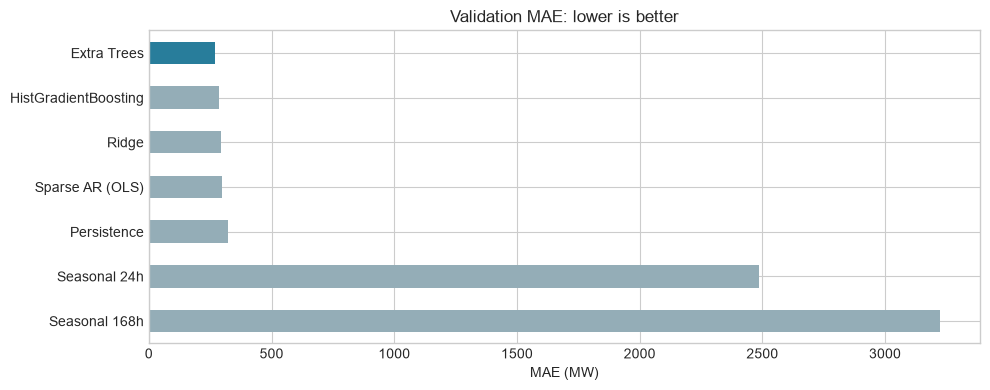

In [9]:
# diff 在原始规则小时轴上计算；缺失值仍为缺失，不把跨两小时误算成一步变化。
train_original_target = energy.loc[
    (energy.index >= TRAIN_START) & (energy.index < VAL_START), TARGET
]
train_mase_scale = train_original_target.diff().abs().mean()
assert np.isfinite(train_mase_scale) and train_mase_scale > 0

validation_rows = []
validation_models = {}
validation_predictions = {}
for name in CANDIDATES:
    started = time.perf_counter()
    fitted_model = make_model(name).fit(X_train, y_train)
    prediction = predict_nonnegative(fitted_model, X_val)
    row = {"model": name, **score_forecast(y_val, prediction, train_mase_scale)}
    row["fit_and_predict_seconds"] = time.perf_counter() - started
    validation_rows.append(row)
    validation_models[name] = fitted_model
    validation_predictions[name] = prediction

validation_table = pd.DataFrame(validation_rows).set_index("model").sort_values("MAE_MW")
persistence_mae = validation_table.loc["Persistence", "MAE_MW"]
validation_table["MAE_gain_vs_persistence_pct"] = 100 * (1 - validation_table["MAE_MW"] / persistence_mae)
best_name = validation_table.index[0]
display(validation_table.round(3))
print(f"根据验证 MAE 选定：{best_name}；此时尚未用测试分数选择模型。")

ax = validation_table["MAE_MW"].sort_values(ascending=False).plot.barh(
    color=["#287d9b" if name == best_name else "#94adb7" for name in validation_table["MAE_MW"].sort_values(ascending=False).index],
    figsize=(10, 4),
)
ax.set(title="Validation MAE: lower is better", xlabel="MAE (MW)", ylabel="")
plt.tight_layout()
plt.show()


### 读取 AR 系数

AR 系数能够说明模型如何组合不同历史值，但滞后特征高度相关，单个系数可能不稳定，也不能直接解读为因果效应。滚动一步评估中，我们每小时更新输入历史，不在验证期重新估计这些系数。


In [10]:
ar_estimator = validation_models["Sparse AR (OLS)"].named_steps["model"]
ar_coefficients = pd.Series(ar_estimator.coef_, index=AR_COLUMNS, name="OLS_coefficient")
display(ar_coefficients.to_frame())
print(f"AR 截距：{ar_estimator.intercept_:.3f} MW")


,OLS_coefficient
target_lag_1,1.146571
target_lag_2,-0.081044
target_lag_3,-0.094317
target_lag_24,-0.001487
target_lag_48,0.007192
target_lag_168,0.001362


AR 截距：117.746 MW


## 8. 合并训练与验证，进行最后一次测试评估

现在锁定刚才选出的模型类型与超参数，用 2015–2017 年重新拟合。测试表只比较这个已选定模型与预先声明的三个基线，**不会用测试排名重新选模型**。

2018 年每小时的预测都只依赖该小时之前的真实历史。把这些因果特征一次性传给 `predict`，是逐小时同一模型预测的向量化实现，不意味着在 2017 年底就知道了 2018 年的真实历史。


In [11]:
fit_mask = X.index < TEST_START
X_fit, y_fit = X.loc[fit_mask], y.loc[fit_mask]
assert X_fit.index.max() < X_test.index.min()

final_model = make_model(best_name).fit(X_fit, y_fit)
final_prediction = predict_nonnegative(final_model, X_test)

# 测试期 MASE 的尺度只从最终拟合区间估计，仍不使用测试标签。
fit_original_target = energy.loc[
    (energy.index >= TRAIN_START) & (energy.index < TEST_START), TARGET
]
final_mase_scale = fit_original_target.diff().abs().mean()
test_predictions = {best_name: final_prediction}
for baseline_name in ["Persistence", "Seasonal 24h", "Seasonal 168h"]:
    if baseline_name not in test_predictions:
        baseline = make_model(baseline_name).fit(X_fit, y_fit)
        test_predictions[baseline_name] = predict_nonnegative(baseline, X_test)

test_table = pd.DataFrame({
    name: score_forecast(y_test, prediction, final_mase_scale)
    for name, prediction in test_predictions.items()
}).T
test_table.index.name = "model"
test_table["role"] = ["selected_on_validation" if name == best_name else "predeclared_baseline" for name in test_table.index]
test_table["MAE_gain_vs_persistence_pct"] = 100 * (
    1 - test_table["MAE_MW"] / test_table.loc["Persistence", "MAE_MW"]
)
display(test_table.round(3))

test_period_mask = (energy.index >= TEST_START) & (energy.index < TEST_END)
available_test_hours = int(test_period_mask.sum())
print(f"最终模型：{best_name}")
print(f"测试有标签小时覆盖率：{len(y_test)}/{available_test_hours} = {len(y_test) / available_test_hours:.2%}")
print("后续测试诊断仅用于解释，不据此修改模型后再次宣称同一测试集是全新评估。")


,MAE_MW,RMSE_MW,R2,MASE,role,MAE_gain_vs_persistence_pct
model,,,,,,
Extra Trees,279.074,576.299,0.970,0.855,selected_on_validation,17.223
Persistence,337.139,650.372,0.961,1.033,predeclared_baseline,0.000
Seasonal 24h,2503.940,3249.020,0.035,7.668,predeclared_baseline,-642.702
Seasonal 168h,3426.519,4344.622,-0.726,10.494,predeclared_baseline,-916.351


最终模型：Extra Trees
测试有标签小时覆盖率：8758/8759 = 99.99%
后续测试诊断仅用于解释，不据此修改模型后再次宣称同一测试集是全新评估。


## 9. 误差诊断：不要只报一个总分

检查一周曲线、大误差、月份及小时分组，以及残差自相关。若误差有明显日周期，可能还有可利用的信息；若极端风电爬坡最难预测，则外部天气预测数据可能比继续加深树更有价值。

同时对照训练期的跳变审计：若最大误差也集中在当地午夜，要先排查数据质量和时间对齐。不能仅凭预测误差很大就断言发生了极端天气，也不能为了改善分数而事后删掉这些测试样本。

这些是测试后的解释，不能一边看测试结果一边反复调参。对模型做了新的选择之后，应该保留新的时间区间作为下一轮检验。


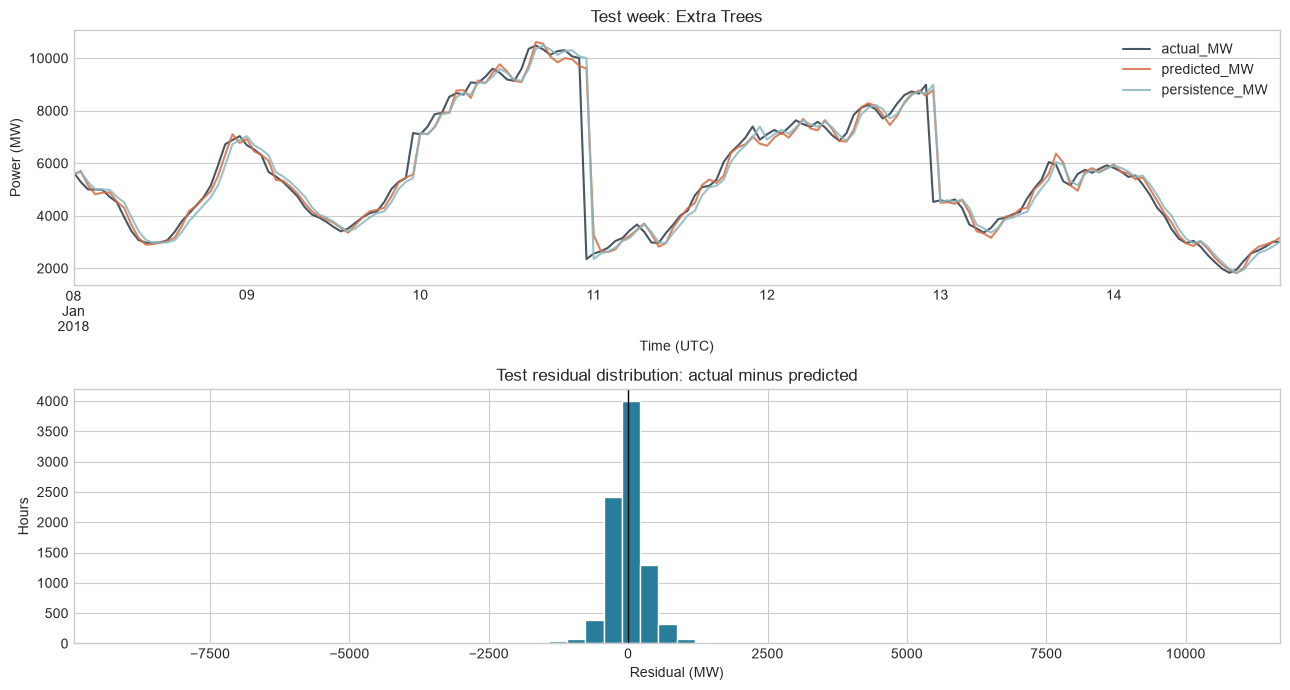

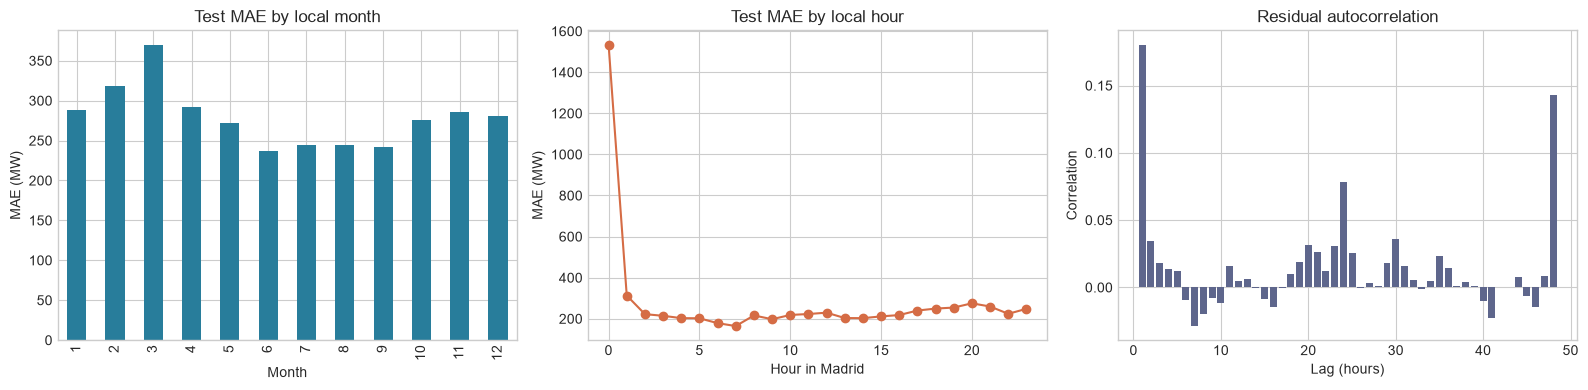

,actual_MW,predicted_MW,persistence_MW,residual_MW,absolute_error_MW,local_time
time,,,,,,
2018-10-31 23:00:00+00:00,13844.0,3133.41,2350.0,10710.59,10710.59,2018-11-01 00:00:00+01:00
2018-01-01 23:00:00+00:00,2158.0,11124.40,13271.0,-8966.40,8966.40,2018-01-02 00:00:00+01:00
2018-12-02 23:00:00+00:00,14572.0,5606.40,5443.0,8965.60,8965.60,2018-12-03 00:00:00+01:00
2018-01-31 23:00:00+00:00,12151.0,3831.86,1957.0,8319.14,8319.14,2018-02-01 00:00:00+01:00
2018-04-30 22:00:00+00:00,11957.0,4400.64,4143.0,7556.36,7556.36,2018-05-01 00:00:00+02:00
2018-11-04 23:00:00+00:00,1945.0,9281.69,9961.0,-7336.69,7336.69,2018-11-05 00:00:00+01:00
2018-03-02 23:00:00+00:00,14915.0,7588.01,8326.0,7326.99,7326.99,2018-03-03 00:00:00+01:00
2018-01-10 23:00:00+00:00,2351.0,9599.95,10002.0,-7248.95,7248.95,2018-01-11 00:00:00+01:00
2018-01-03 23:00:00+00:00,5669.0,12746.20,15112.0,-7077.20,7077.20,2018-01-04 00:00:00+01:00


In [12]:
diagnostics = pd.DataFrame({
    "actual_MW": y_test,
    "predicted_MW": final_prediction,
    "persistence_MW": test_predictions["Persistence"],
})
diagnostics["residual_MW"] = diagnostics["actual_MW"] - diagnostics["predicted_MW"]
diagnostics["absolute_error_MW"] = diagnostics["residual_MW"].abs()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
week = diagnostics.loc["2018-01-08":"2018-01-14"]
week[["actual_MW", "predicted_MW", "persistence_MW"]].plot(
    ax=axes[0], color=["#26394a", "#d56c45", "#8ab7be"], alpha=0.85,
)
axes[0].set(title=f"Test week: {best_name}", ylabel="Power (MW)", xlabel="Time (UTC)")
diagnostics["residual_MW"].hist(bins=60, ax=axes[1], color="#287d9b", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set(title="Test residual distribution: actual minus predicted", xlabel="Residual (MW)", ylabel="Hours")
plt.tight_layout()
plt.show()

test_local = diagnostics.index.tz_convert(LOCAL_TZ)
monthly_mae = diagnostics["absolute_error_MW"].groupby(test_local.month).mean()
hourly_mae = diagnostics["absolute_error_MW"].groupby(test_local.hour).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
monthly_mae.plot(kind="bar", ax=axes[0], color="#287d9b")
axes[0].set(title="Test MAE by local month", xlabel="Month", ylabel="MAE (MW)")
hourly_mae.plot(marker="o", ax=axes[1], color="#d56c45")
axes[1].set(title="Test MAE by local hour", xlabel="Hour in Madrid", ylabel="MAE (MW)")

# 补回未评分的缺失小时，再计算残差相关性，避免把相邻行误当成相邻小时。
hourly_residual = diagnostics["residual_MW"].asfreq("h")
residual_lags = range(1, 49)
residual_acf = [hourly_residual.corr(hourly_residual.shift(k)) for k in residual_lags]
axes[2].bar(list(residual_lags), residual_acf, color="#5e668c")
axes[2].set(title="Residual autocorrelation", xlabel="Lag (hours)", ylabel="Correlation")
plt.tight_layout()
plt.show()

largest_errors = diagnostics.nlargest(10, "absolute_error_MW").round(2).copy()
# 同时显示当地时间，便于检查大误差是否集中在午夜或夏令时转换附近。
largest_errors["local_time"] = largest_errors.index.tz_convert(LOCAL_TZ)
display(largest_errors)


## 10. 模型解释：置换重要性

固定最终模型，打乱某一列，看 MAE 变差多少。为了缩短运行时间，每 6 条可评分的测试样本抽取 1 条，每列重复 3 次；原始缺失标签被排除，所以这里不保证严格相隔 6 小时。这个步骤**不会重训练或重新选择模型**。

滞后列之间高度相关，单列置换还可能制造不自然的历史组合，所以重要性只能作为预测关联的辅助诊断，不能视为因果解释。分数接近零或为负不自动意味着应该删除该列并反复尝试同一测试集。


,feature,MAE_increase_MW,repeat_std_MW
0,target_lag_1,2777.513,13.952
1,target_lag_2,357.961,5.961
8,target_mean_6h,100.530,1.574
2,target_lag_3,61.767,0.826
32,hour_sin,14.553,0.855
33,hour_cos,10.426,1.587
9,target_std_6h,9.671,1.802
3,target_lag_6,7.898,0.194
14,generation solar__lag_1,2.677,0.339
15,generation solar__lag_24,2.426,0.167


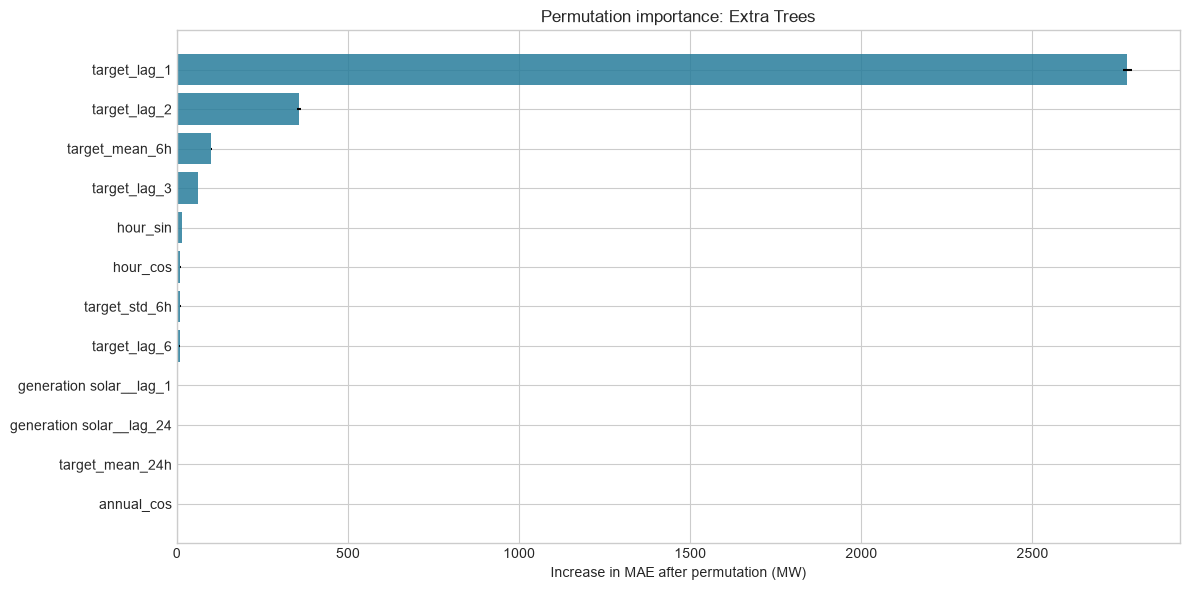

In [13]:
def negative_clipped_mae(estimator, features, labels):
    # 与正式评估保持同一非负截断规则；sklearn 约定分数越高越好，所以 MAE 加负号。
    return -mean_absolute_error(labels, predict_nonnegative(estimator, features))

interpret_X = X_test.iloc[::6]
interpret_y = y_test.iloc[::6]
importance = permutation_importance(
    final_model, interpret_X, interpret_y,
    # 置换层串行，树模型内部至多用两个线程，避免嵌套并行和多进程复制模型。
    scoring=negative_clipped_mae, n_repeats=3, random_state=SEED, n_jobs=1,
)
importance_table = pd.DataFrame({
    "feature": X_test.columns,
    "MAE_increase_MW": importance.importances_mean,
    "repeat_std_MW": importance.importances_std,
}).sort_values("MAE_increase_MW", ascending=False)
display(importance_table.head(12).round(3))

top = importance_table.head(12).sort_values("MAE_increase_MW")
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top["feature"], top["MAE_increase_MW"], xerr=top["repeat_std_MW"], color="#287d9b", alpha=0.85)
ax.set(title=f"Permutation importance: {best_name}", xlabel="Increase in MAE after permutation (MW)")
plt.tight_layout()
plt.show()


## 11. 面试时如何修改与讲解

1. **先确认预测目标。**预测某个来源发电量、总负荷和电价是不同任务。这里默认风电；修改 `TARGET` 为 `generation solar` 后，需重跑全部单元格并重新审视夜间零值和周期，同时把固定的 Wind 图标签改成新目标名称。
2. **问清哪些列在预测时已知。**“给三列预测第四列”可能是同一时刻的缺失值估计，也可能是未来预测；两者的信息集不同。若预先给定的是未来天气预报，可以使用，但要按预报发布时间对齐。
3. **先做结构与时间检查。**展示缺失、时区、频率、常量列，解释为什么不随机切分、不填标签、不使用未来数据插值。
4. **先跑 persistence，再跑 AR。**复杂模型必须证明比这些基线好，而不能只和常数均值比较。诚实报告没有胜出的模型。
5. **最后解释误差。**报告 MAE 的 MW 含义、相对 persistence 的改进、极端爬坡误差、误差是否随月份变化。
6. **若改成提前 24 小时或一次预测全年，必须重做特征和评估。**不能把本 notebook 的测试期真实 lag 1 继续当作固定预测起点可用的数据。应选择递归预测、直接多步模型，或只用起点之前的历史和起点时已知的外生变量。

在 6 小时项目里，可以先用约 1.5 小时处理数据和 EDA，约 2 小时完成基线与模型，约 1 小时做误差分析，余下时间整理说明、检查因果性并从头重跑。模型数量和时间分配可以按题目调整。


In [14]:
# 保留运行环境，便于之后复现；版本不同可能导致少量指标差异。
versions = {"python": platform.python_version()}
for package in ["numpy", "pandas", "matplotlib", "scikit-learn"]:
    versions[package] = importlib.metadata.version(package)
display(pd.Series(versions, name="version"))

assert np.isfinite(validation_table[["MAE_MW", "RMSE_MW", "R2", "MASE"]].to_numpy()).all()
assert np.isfinite(test_table[["MAE_MW", "RMSE_MW", "R2", "MASE"]].to_numpy()).all()
assert len(final_prediction) == len(y_test)
print("全部流程完成：下载、EDA、因果特征、验证选择、最终测试和误差诊断。")


python          3.12.14
numpy             2.5.3
pandas            3.0.6
matplotlib       3.11.2
scikit-learn      1.9.1
Name: version, dtype: str

全部流程完成：下载、EDA、因果特征、验证选择、最终测试和误差诊断。
